## Netflix Movies & TV Shows — Exploratory Data Analysis

#### Importing the required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

#### Reading the Dataset and checking its content

In [2]:
df = pd.read_csv("./netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


#### Dividing the dataset into Movies and TV Shows based on their type

In [4]:
movies = df[df["type"] == "Movie"]
tv_shows = df[df["type"] != "Movie"]

movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [5]:
tv_shows.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


##### Checking the shape of the movies and tv_shows dataframe

We observe that the number of movies is more than twice the number of TV shows.

In [6]:
no_of_tv_shows = tv_shows.shape
no_of_movies = movies.shape

print("Movies :", no_of_movies)
print("TV Shows :", no_of_tv_shows)

Movies : (6131, 12)
TV Shows : (2676, 12)


##### Checking the null values in movies and tv shows

In [7]:
null_in_M = movies.isnull().sum()
null_in_M

show_id           0
type              0
title             0
director        188
cast            475
country         440
date_added        0
release_year      0
rating            2
duration          3
listed_in         0
description       0
dtype: int64

In [8]:
null_in_TV = tv_shows.isnull().sum()
null_in_TV

show_id            0
type               0
title              0
director        2446
cast             350
country          391
date_added        10
release_year       0
rating             2
duration           0
listed_in          0
description        0
dtype: int64

##### Percentage missing in Movies vs TV Shows

In [9]:
percent_Null_M = null_in_M / len(movies) * 100
percent_Null_M

show_id         0.000000
type            0.000000
title           0.000000
director        3.066384
cast            7.747513
country         7.176643
date_added      0.000000
release_year    0.000000
rating          0.032621
duration        0.048932
listed_in       0.000000
description     0.000000
dtype: float64

In [10]:
percent_Null_Tv = null_in_TV / len(tv_shows) * 100
percent_Null_Tv

show_id          0.000000
type             0.000000
title            0.000000
director        91.405082
cast            13.079223
country         14.611360
date_added       0.373692
release_year     0.000000
rating           0.074738
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

There are no duplicate values present in either the movies or tv shows data.

In [11]:
duplicate_M = movies.duplicated().sum()
duplicate_TV = tv_shows.duplicated().sum()

print("Duplicate movies:", duplicate_M)
print("Duplicate TV shows:", duplicate_TV)

Duplicate movies: 0
Duplicate TV shows: 0


### Data Cleaning

Before diving into visual analysis, we handle missing values and engineer a few useful columns:
- Fill missing `director`, `cast`, and `country` with `"Unknown"` (dropping them would lose too much data, especially for TV shows where 91% of `director` is missing).
- Drop the handful of rows missing `rating` (only 4 rows) since it's not worth imputing.
- Convert `date_added` to a proper datetime and extract the year/month a title was added to Netflix.
- Extract a numeric `duration` value (minutes for movies, number of seasons for TV shows).

In [12]:
df_clean = df.copy()

for col in ["director", "cast", "country"]:
    df_clean[col] = df_clean[col].fillna("Unknown")

df_clean = df_clean.dropna(subset=["rating"])

df_clean["date_added"] = pd.to_datetime(df_clean["date_added"].str.strip(), errors="coerce")
df_clean["year_added"] = df_clean["date_added"].dt.year
df_clean["month_added"] = df_clean["date_added"].dt.month_name()

df_clean["duration_num"] = df_clean["duration"].str.extract(r"(\d+)").astype(float)

df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,2.0


### 1. Movies vs TV Shows — Overall Split

Netflix's catalog skews heavily toward movies.

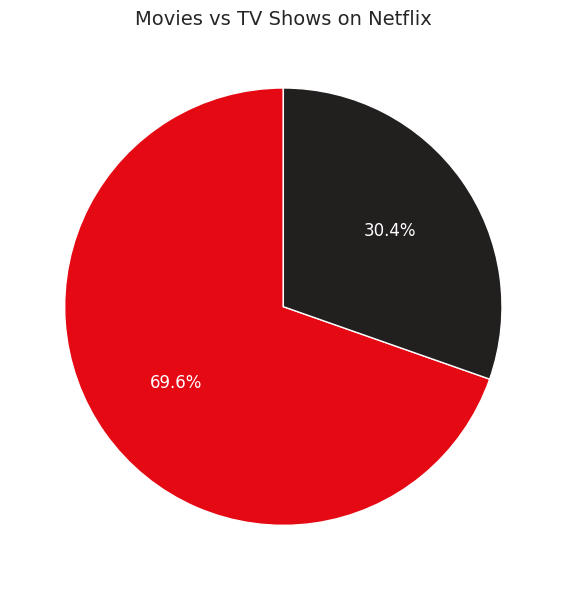

In [13]:
type_counts = df_clean["type"].value_counts()

plt.figure(figsize=(6, 6))
colors = ["#E50914", "#221f1f"]
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
        startangle=90, colors=colors, textprops={"color": "white", "fontsize": 12})
plt.title("Movies vs TV Shows on Netflix", fontsize=14)
plt.tight_layout()
plt.savefig("type_split.png", dpi=120)
plt.show()

### 2. Content Added to Netflix Over the Years

Netflix's library grew rapidly between 2015 and 2019, then growth slowed down (2020-2021 also reflects
pandemic-era production slowdowns).

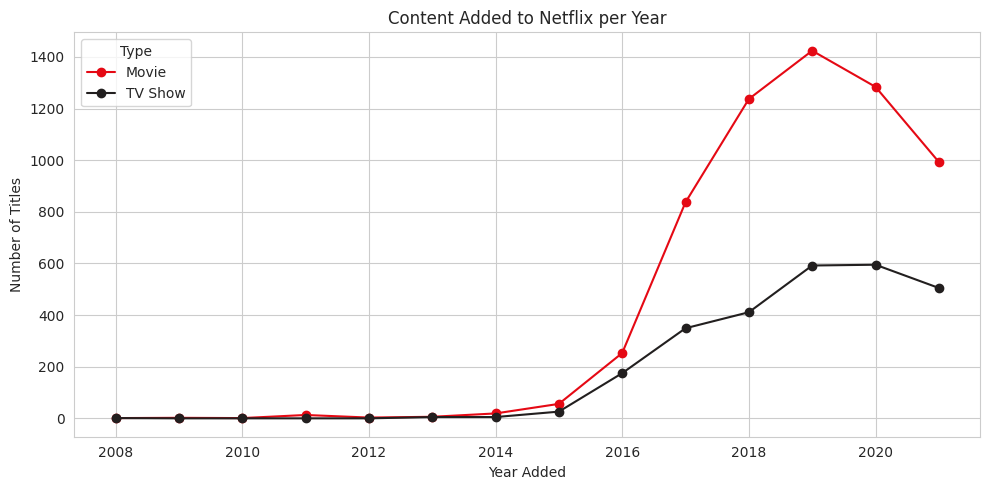

In [14]:
yearly = df_clean.dropna(subset=["year_added"])
yearly = yearly[yearly["year_added"] >= 2008]  # drop stray/erroneous early years

trend = yearly.groupby(["year_added", "type"]).size().unstack(fill_value=0)

trend.plot(kind="line", marker="o", figsize=(10, 5), color=["#E50914", "#221f1f"])
plt.title("Content Added to Netflix per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.tight_layout()
plt.savefig("content_by_year.png", dpi=120)
plt.show()

### 3. Top 10 Content-Producing Countries

Since a title can list multiple countries, we split and count each one individually.
The United States and India dominate Netflix's catalog by a wide margin.

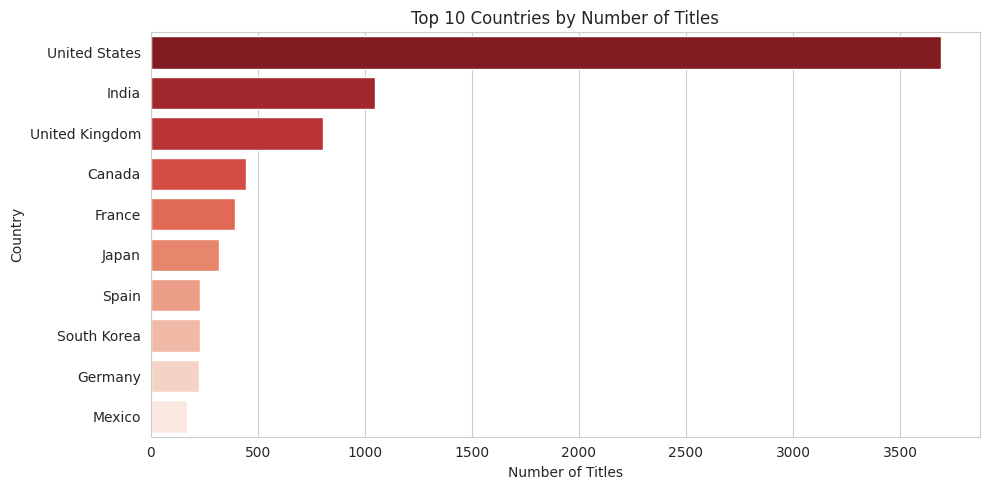

In [15]:
countries = df_clean["country"].str.split(", ").explode()
countries = countries[countries != "Unknown"]
top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette="Reds_r", legend=False)
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_countries.png", dpi=120)
plt.show()

### 4. Most Common Genres

The `listed_in` column contains comma-separated genres per title. International Movies, Dramas,
and Comedies are the most represented categories.

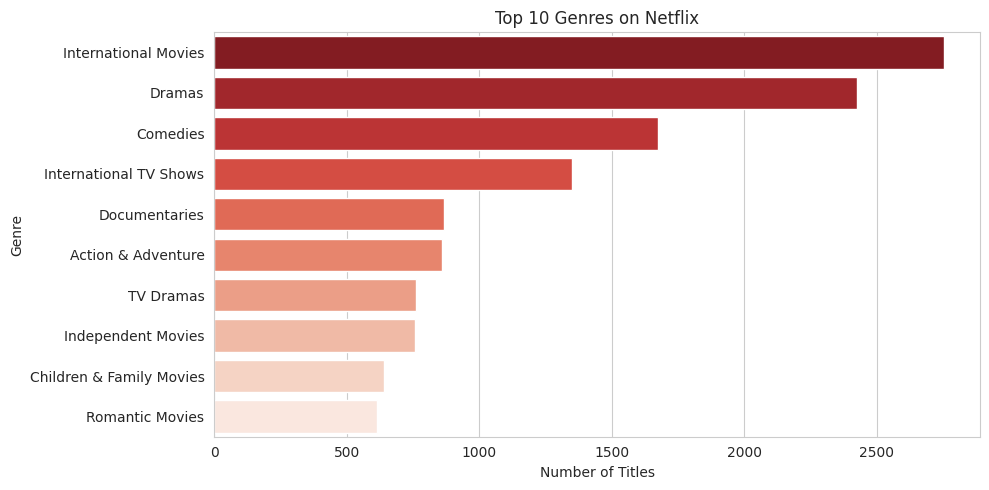

In [16]:
genres = df_clean["listed_in"].str.split(", ").explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index,
            palette="Reds_r", legend=False)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("top_genres.png", dpi=120)
plt.show()

### 5. Content Rating Distribution

TV-MA and TV-14 are the most common ratings, showing Netflix's catalog leans toward mature/teen audiences
rather than young children's content.

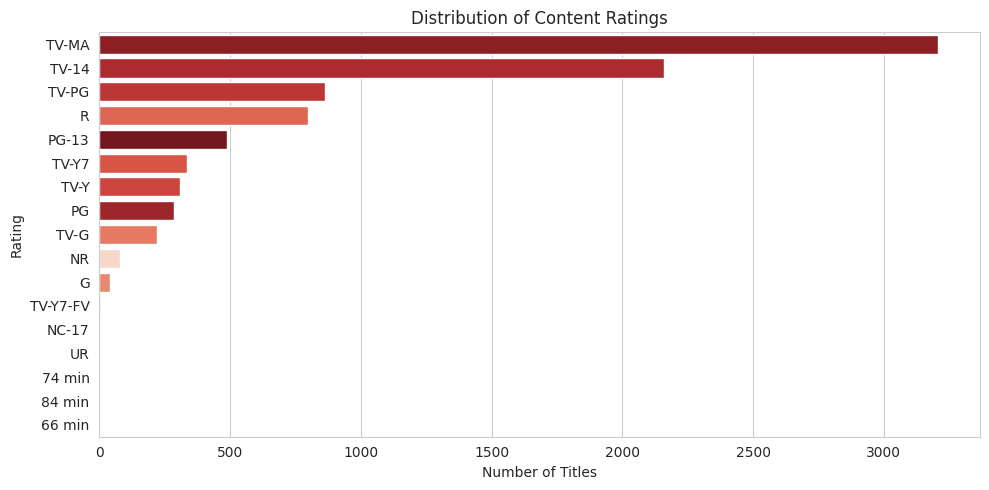

In [17]:
plt.figure(figsize=(10, 5))
rating_order = df_clean["rating"].value_counts().index
sns.countplot(data=df_clean, y="rating", order=rating_order, hue="rating",
              palette="Reds_r", legend=False)
plt.title("Distribution of Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=120)
plt.show()

### 6. Movie Duration Distribution

Most movies on Netflix fall between 80-120 minutes, consistent with typical feature film length.

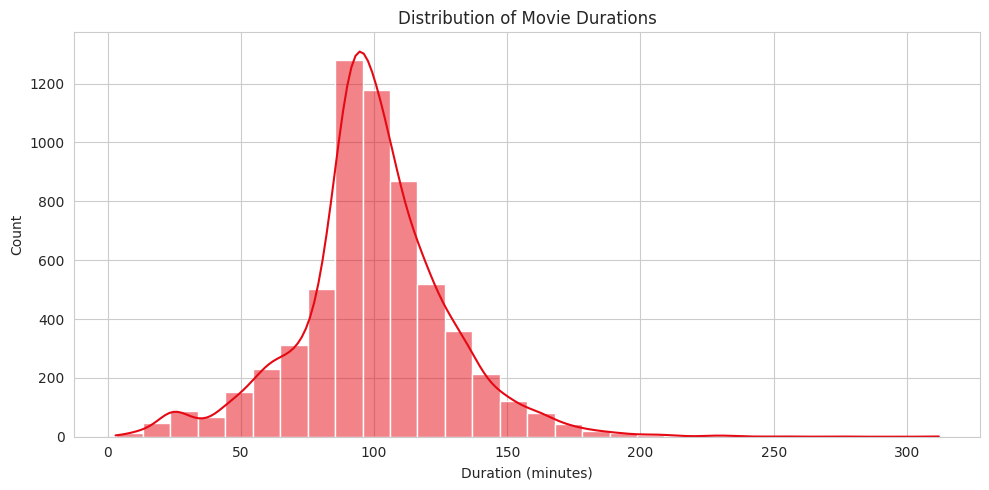

Average movie duration: 99.6 minutes
Median movie duration: 98.0 minutes


In [18]:
movie_durations = df_clean[df_clean["type"] == "Movie"]["duration_num"].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(movie_durations, bins=30, color="#E50914", kde=True)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("movie_duration.png", dpi=120)
plt.show()

print("Average movie duration:", round(movie_durations.mean(), 1), "minutes")
print("Median movie duration:", movie_durations.median(), "minutes")

### 7. TV Show Seasons Distribution

The vast majority of TV shows on Netflix have just 1 season, suggesting Netflix's catalog is
dominated by limited series/one-off shows rather than long-running series.

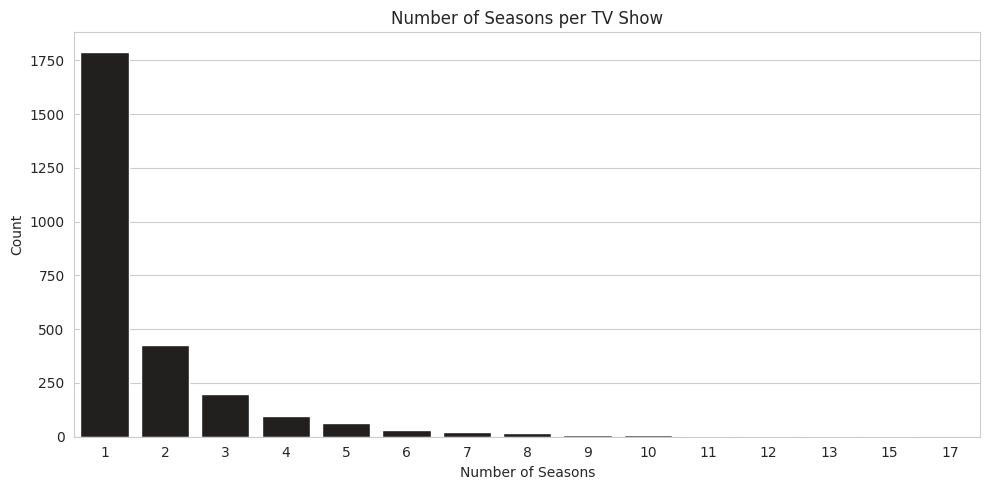

Titles with only 1 season: 67.0 %


In [19]:
tv_seasons = df_clean[df_clean["type"] == "TV Show"]["duration_num"].dropna()

plt.figure(figsize=(10, 5))
sns.countplot(x=tv_seasons.astype(int), color="#221f1f")
plt.title("Number of Seasons per TV Show")
plt.xlabel("Number of Seasons")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("tv_seasons.png", dpi=120)
plt.show()

print("Titles with only 1 season:",
      round((tv_seasons == 1).sum() / len(tv_seasons) * 100, 1), "%")

### 8. Release Year Trend

Most content on the platform was released in the last decade — Netflix's catalog is
weighted heavily toward recent releases rather than older/classic titles.

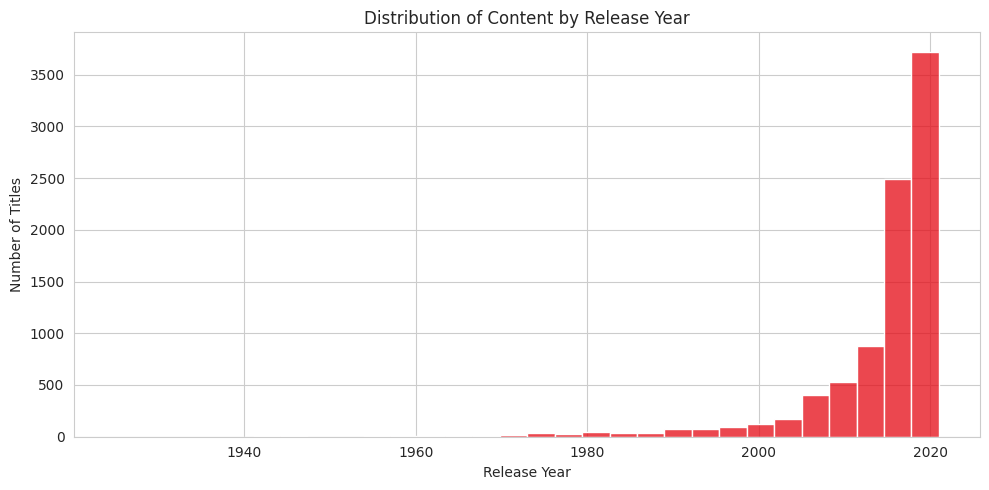

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["release_year"], bins=30, color="#E50914")
plt.title("Distribution of Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("release_year.png", dpi=120)
plt.show()

### 9. Most Frequent Directors

(Excluding "Unknown"). A handful of directors — many associated with documentaries and
stand-up comedy specials — appear disproportionately often.

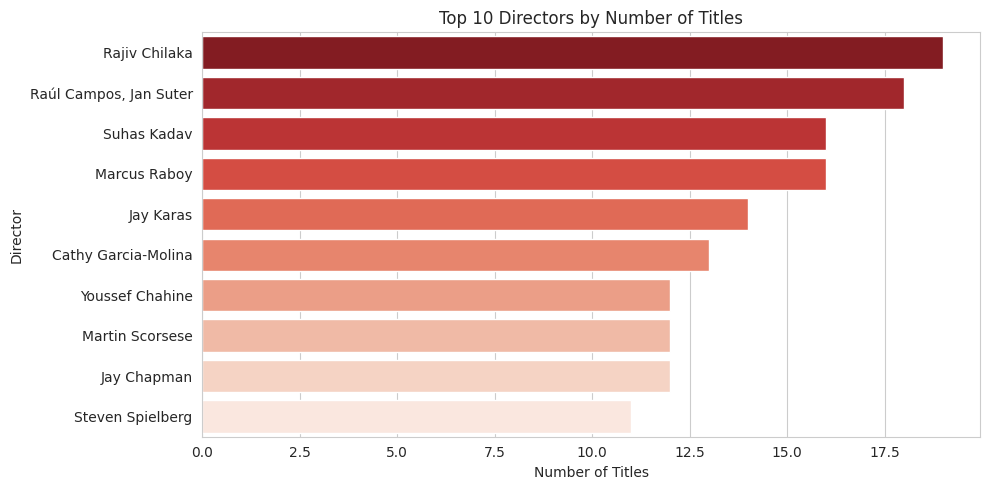

In [21]:
top_directors = df_clean[df_clean["director"] != "Unknown"]["director"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index,
            palette="Reds_r", legend=False)
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.tight_layout()
plt.savefig("top_directors.png", dpi=120)
plt.show()

## Key Insights

1. **Movies dominate the catalog** — roughly 70% of titles are movies vs. 30% TV shows.
2. **Rapid catalog growth 2015-2019**, slowing down after 2020.
3. **The US and India are the top content-producing countries**, followed by the UK.
4. **International Movies, Dramas, and Comedies** are the most common genres.
5. **TV-MA and TV-14** are the most frequent ratings — the catalog skews toward mature/teen audiences.
6. **Most movies run 80-120 minutes**; most TV shows have only **1 season**.
7. **Content is skewed toward recent releases**, with a sharp increase in titles from 2015 onward.

### Possible Next Steps
- Build a simple content-based recommender using `listed_in` (genres) and `description` (TF-IDF + cosine similarity).
- Analyze seasonal patterns in `month_added` to see if Netflix has a release-timing strategy.
- Compare genre popularity trends by country.